<a href="https://colab.research.google.com/github/Shrinkhal01/hybrid-xai-lung-nodule/blob/main/hybrid_xai_lung_nodule.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cell 1 — Mount Google Drive and unzip LIDC-IDRI

In [19]:
from google.colab import drive
drive.mount('/content/drive')

print("Dataset added successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset added successfully!


# Cell 2 — Configure PyLIDC

In [20]:
import os

colab_path = "/content/drive/MyDrive/manifest-1786753014866/LIDC-IDRI"

# Check that the dataset exists
print("Dataset exists:", os.path.exists(colab_path))

# Create PyLIDC configuration file
with open("/root/.pylidcrc", "w") as f:
    f.write("[dicom]\n")
    f.write(f"path={colab_path}\n")

print("PyLIDC configuration created!")
print("DICOM path:", colab_path)

Dataset exists: True
PyLIDC configuration created!
DICOM path: /content/drive/MyDrive/manifest-1786753014866/LIDC-IDRI


# Cell 3 — Install PyLIDC

In [22]:
!pip install -q pylidc


## import everything:

In [23]:
import pylidc as pl
import numpy as np
import matplotlib.pyplot as plt

# Compatibility fix for older PyLIDC code
np.int = int

print("PyLIDC imported successfully!")

PyLIDC imported successfully!


# Cell 4 — Load the first CT scan

In [24]:
# Query the database for the first scan
scan = pl.query(pl.Scan).first()

if scan is None:
    print("No scans found. Check your dataset path.")
else:
    print(f"Loaded Patient ID: {scan.patient_id}")
    print(f"Study UID: {scan.study_instance_uid}")

Loaded Patient ID: LIDC-IDRI-0078
Study UID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277323131167631068432


# Cell 5 — Find the nodules

In [25]:
# Cluster the radiologists' annotations
nodules = scan.cluster_annotations()

print(f"Found {len(nodules)} distinct nodules in this scan.")

Found 4 distinct nodules in this scan.


# Cell 6 — Get the first nodule

In [26]:
# First nodule
nodule = nodules[0]

print(f"Number of annotations for this nodule: {len(nodule)}")

# First radiologist annotation
annotation = nodule[0]

print(f"Malignancy rating: {annotation.malignancy}")
print(f"Nodule diameter: {annotation.diameter:.2f} mm")

Number of annotations for this nodule: 4
Malignancy rating: 3
Nodule diameter: 19.50 mm


# Cell 7 — Get CT volume, nodule volume, mask and bounding box

Successfully loaded database info for: LIDC-IDRI-0006
Fetching 3D CT volume (this might take a few seconds)...
Loading dicom files ... This may take a moment.
Full CT scan shape: (512, 512, 133)
Cropped Nodule shape: (11, 11, 2)
------------------------------


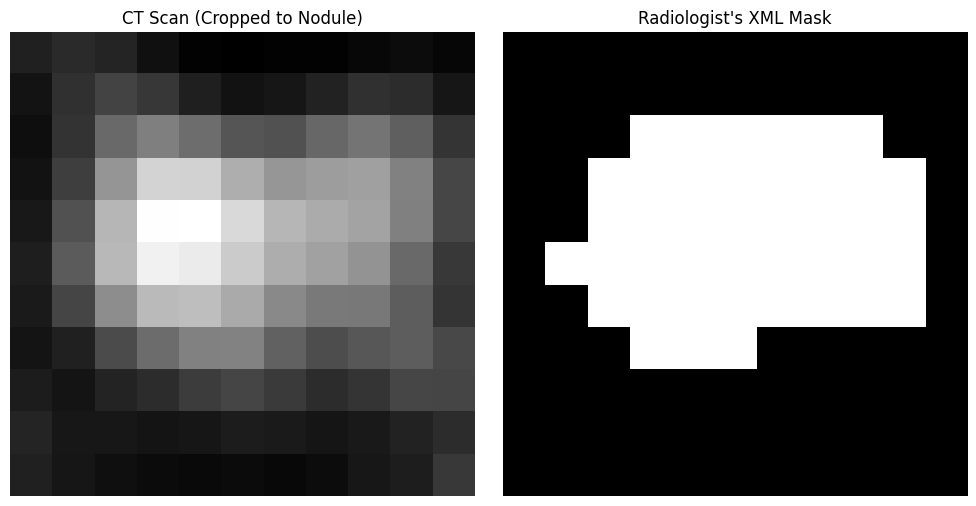

In [46]:
import pylidc as pl
import matplotlib.pyplot as plt

# 1. Specifically ask for Patient 0006 (the one you actually downloaded!)
scan = pl.query(pl.Scan).filter(pl.Scan.patient_id == 'LIDC-IDRI-0006').first()

print(f"Successfully loaded database info for: {scan.patient_id}")
print("Fetching 3D CT volume (this might take a few seconds)...")

# 2. Now this will work, because the folder LIDC-IDRI-0006 exists on your Drive
vol = scan.to_volume()

# 3. Find the nodules for Patient 0006
nodules = scan.cluster_annotations()
annotation = nodules[0][0]

# 4. Get the bounding box and radiologist mask
bbox = annotation.bbox()
mask = annotation.boolean_mask()

# 5. Crop the CT scan
nodule_vol = vol[bbox]

print(f"Full CT scan shape: {vol.shape}")
print(f"Cropped Nodule shape: {nodule_vol.shape}")
print("-" * 30)

# 6. Visualize the middle slice
mid_slice = int(mask.shape[2] / 2)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(nodule_vol[:, :, mid_slice], cmap=plt.cm.gray)
ax[0].set_title("CT Scan (Cropped to Nodule)")
ax[0].axis('off')

ax[1].imshow(mask[:, :, mid_slice], cmap=plt.cm.gray)
ax[1].set_title("Radiologist's XML Mask")
ax[1].axis('off')

plt.tight_layout()
plt.show()

# Average Malignancy & Assign Labels

In [47]:
def get_nodule_label(nodule_annotations):
    # Average malignancy across all radiologists who annotated this nodule
    scores = [ann.malignancy for ann in nodule_annotations]
    avg_score = np.mean(scores)

    # Binary Classification Split:
    # 1-2: Benign (0), 4-5: Malignant (1), 3: Ambiguous (Drop or ignore)
    if avg_score < 3.0:
        return 0  # Benign
    elif avg_score > 3.0:
        return 1  # Malignant
    else:
        return None  # Neutral / Ambiguous

# Cell 8 — Full Pipeline Data Processor & Exporter

In [48]:
import os
import numpy as np
import pylidc as pl
from scipy.ndimage import zoom

# 1. Configuration Parameters

In [49]:
OUTPUT_DIR = "/content/drive/MyDrive/processed_dataset"
TARGET_SHAPE = (32, 32, 32)  # Standardized 3D Volume Input Size
HU_MIN, HU_MAX = -1000.0, 400.0  # Lung Windowing Ranges in Hounsfield Units

os.makedirs(OUTPUT_DIR, exist_ok=True)

# 2. Helper Functions for Processing & Padding

In [50]:
def normalize_hu(volume):
    """Clips Hounsfield Units to standard lung window [-1000, 400] and normalizes to [0, 1]."""
    volume = np.clip(volume, HU_MIN, HU_MAX)
    volume = (volume - HU_MIN) / (HU_MAX - HU_MIN)
    return volume.astype(np.float32)

def resize_volume_3d(volume, target_shape=TARGET_SHAPE):
    """Resizes any cropped nodule volume to a uniform target 3D shape."""
    factors = [t / float(s) for t, s in zip(target_shape, volume.shape)]
    return zoom(volume, factors, order=1)

def compute_malignancy_label(cluster):
    """
    Computes average malignancy across all radiologists:
    - Label 0: Benign (mean < 3.0)
    - Label 1: Malignant (mean > 3.0)
    - None: Ambiguous (mean == 3.0, dropped to prevent label noise)
    """
    scores = [ann.malignancy for ann in cluster]
    avg_score = np.mean(scores)

    if avg_score < 3.0:
        return 0  # Benign
    elif avg_score > 3.0:
        return 1  # Malignant
    return None  # Drop indeterminate cases

# 3. Extraction Loop Across All Downloaded Scans

In [51]:
processed_images = []
processed_labels = []
processed_ids = []

scans = pl.query(pl.Scan).all()
print(f"Total scans found in PyLIDC database: {len(scans)}")

nodule_counter = 0

for scan in scans:
    # Check if DICOM folder for this patient actually exists on Drive
    patient_path = os.path.join(colab_path, scan.patient_id)
    if not os.path.exists(patient_path):
        continue

    print(f"\nProcessing {scan.patient_id}...")
    try:
        vol = scan.to_volume(verbose=False)
    except Exception as e:
        print(f"Skipping {scan.patient_id} due to loading error: {e}")
        continue

    nodule_clusters = scan.cluster_annotations()

    for cluster in nodule_clusters:
        label = compute_malignancy_label(cluster)
        if label is None:
            continue  # Skip ambiguous nodules

        # Use first annotation's bounding box as ROI base
        bbox = cluster[0].bbox()
        nodule_crop = vol[bbox]

        # Apply HU Normalization & Resizing
        normalized_crop = normalize_hu(nodule_crop)
        resized_crop = resize_volume_3d(normalized_crop, TARGET_SHAPE)

        processed_images.append(resized_crop)
        processed_labels.append(label)
        processed_ids.append(f"{scan.patient_id}_nodule_{nodule_counter}")
        nodule_counter += 1

Total scans found in PyLIDC database: 1018

Processing LIDC-IDRI-0006...

Processing LIDC-IDRI-0010...


# 4. Save Extracted Arrays to Google Drive

In [52]:
X = np.array(processed_images, dtype=np.float32)
y = np.array(processed_labels, dtype=np.int64)

np.save(os.path.join(OUTPUT_DIR, "X_nodules.npy"), X)
np.save(os.path.join(OUTPUT_DIR, "y_labels.npy"), y)

print("\n" + "=" * 40)
print("PROCESSING COMPLETE!")
print(f"Total Nodule Samples Extracted: {len(X)}")
print(f"Final Data Matrix Shape (X): {X.shape}")
print(f"Final Labels Matrix Shape (y): {y.shape}")
print(f"Class Distribution -> Benign (0): {np.sum(y == 0)}, Malignant (1): {np.sum(y == 1)}")
print(f"Saved dataset files to: {OUTPUT_DIR}")
print("=" * 40)


PROCESSING COMPLETE!
Total Nodule Samples Extracted: 5
Final Data Matrix Shape (X): (5, 32, 32, 32)
Final Labels Matrix Shape (y): (5,)
Class Distribution -> Benign (0): 4, Malignant (1): 1
Saved dataset files to: /content/drive/MyDrive/processed_dataset
